In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score

from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (8, 4)

In [2]:
cwd = os.getcwd()
path = os.path.join(cwd, 'data_titanic')

df_train = pd.read_csv(os.path.join(path, 'train.csv')).set_index('PassengerId')
df_test  = pd.read_csv(os.path.join(path, 'test.csv')).set_index('PassengerId')

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')
df_train.head()

Train: (891, 11)  |  Test: (418, 10)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [4]:
df_train.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


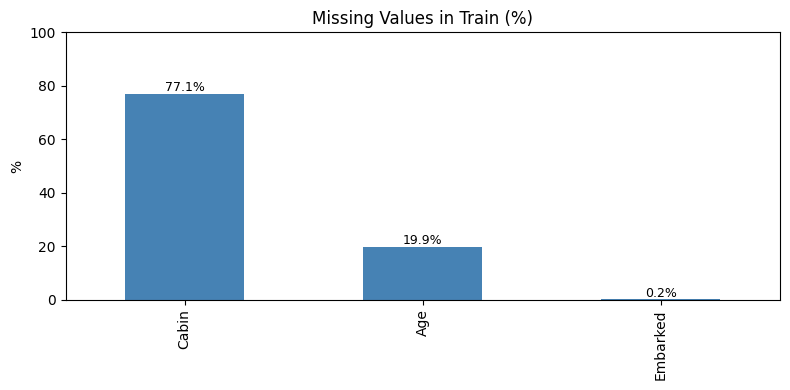

In [5]:
def plot_missing_data(df, title='Missing Values (%)',color = 'steelblue'):
    missing = df.isna().mean() * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    
    missing.plot(kind='bar', color=color)
    plt.title(title)
    plt.ylabel('%')
    plt.ylim(0, 100)
    for i, v in enumerate(missing):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
plot_missing_data(df_train, title='Missing Values in Train (%)', color='steelblue')

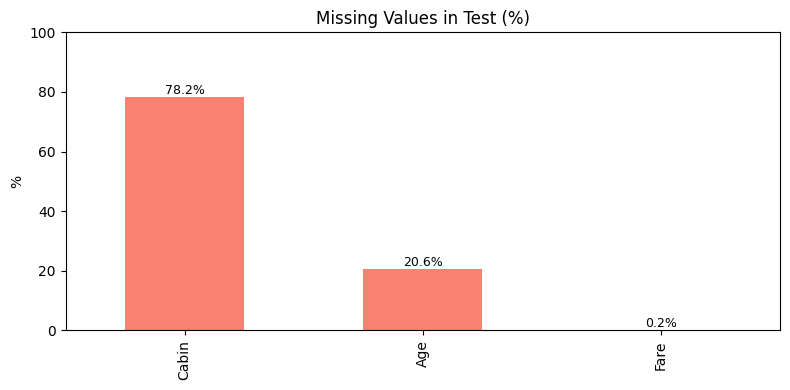

In [6]:
plot_missing_data(df_test, title='Missing Values in Test (%)', color='salmon')

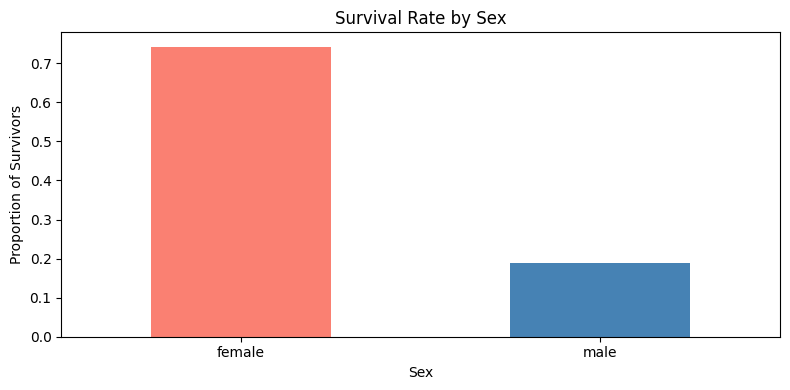

In [7]:
df_train.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Survival Rate by Sex')
plt.ylabel('Proportion of Survivors')
plt.xticks(ticks=[0, 1], labels=['female', 'male'], rotation=0)
plt.tight_layout()
plt.show()

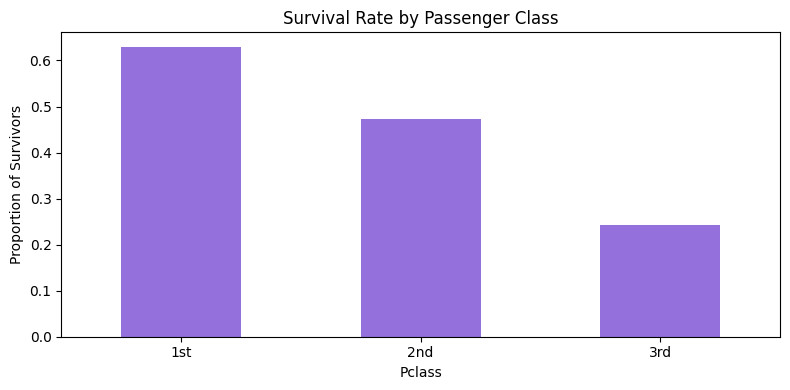

In [8]:
df_train.groupby('Pclass')['Survived'].mean().plot(kind='bar', color='mediumpurple')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Proportion of Survivors')
plt.xticks(ticks=[0, 1, 2], labels=['1st', '2nd', '3rd'], rotation=0)
plt.tight_layout()
plt.show()

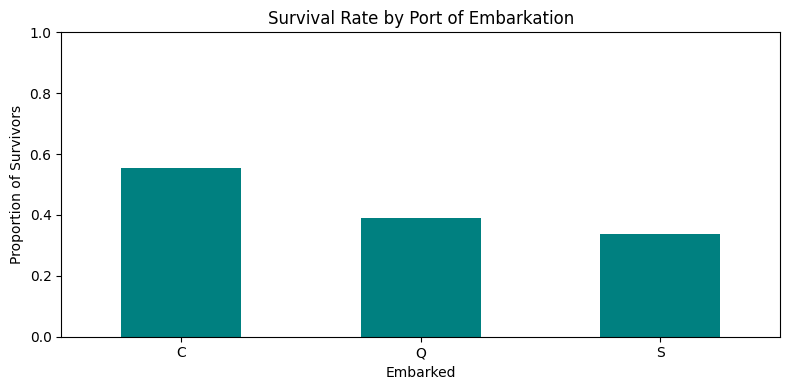

In [9]:
df_train.groupby('Embarked')['Survived'].mean().plot(kind='bar', color='teal')
plt.title('Survival Rate by Port of Embarkation')
plt.ylabel('Proportion of Survivors')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

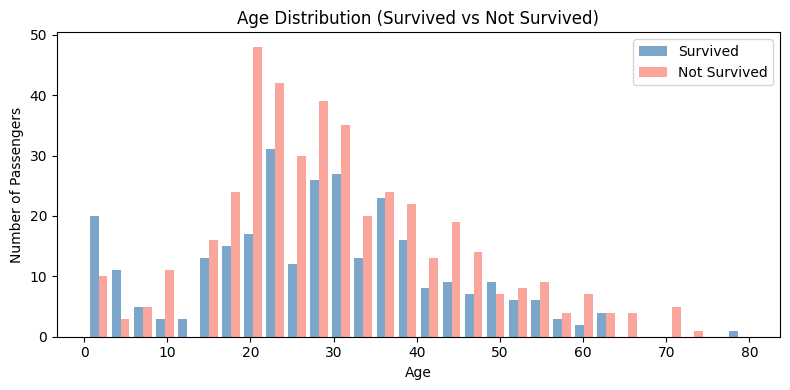

In [10]:
survived= df_train[df_train['Survived'] == 1]['Age'].dropna()
not_survived = df_train[df_train['Survived'] == 0]['Age'].dropna()

plt.hist([survived, not_survived], bins=30, label=['Survived', 'Not Survived'],
         color=['steelblue', 'salmon'], alpha=0.7)
plt.title('Age Distribution (Survived vs Not Survived)')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend()
plt.tight_layout()
plt.show()

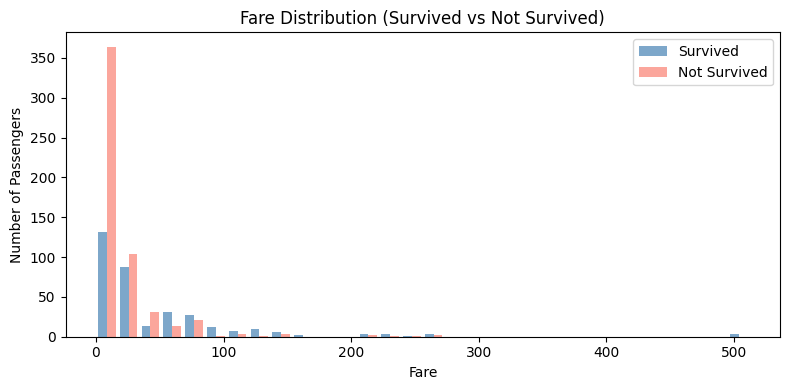

In [11]:
plt.hist([df_train[df_train['Survived']==1]['Fare'],
          df_train[df_train['Survived']==0]['Fare']],
         bins=30, label=['Survived', 'Not Survived'], color=['steelblue', 'salmon'], alpha=0.7)
plt.title('Fare Distribution (Survived vs Not Survived)')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.legend()
plt.tight_layout()
plt.show()

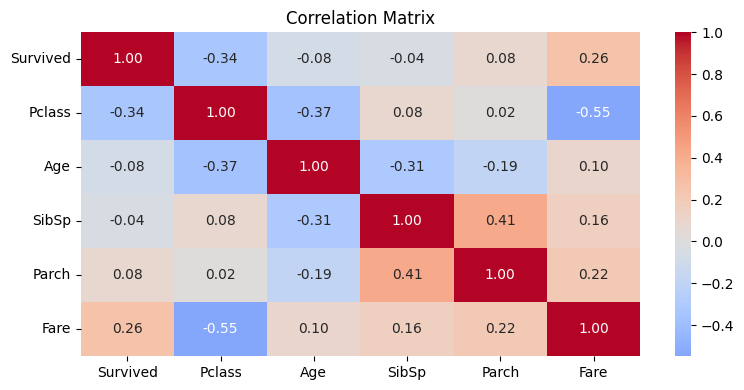

In [12]:
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
sns.heatmap(df_train[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [13]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())
df_test['Age']  = df_test['Age'].fillna(df_test['Age'].median())

df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])

df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())

columns_to_drop = ['Name', 'Ticket', 'Cabin']
df_train = df_train.drop(columns=columns_to_drop)
df_test  = df_test.drop(columns=columns_to_drop)

print('Skipped train:', df_train.isna().sum().sum())
print('Skipped test: ', df_test.isna().sum().sum())
df_train.head()

Skipped train: 0
Skipped test:  0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


In [14]:
le = LabelEncoder()

for col in df_train.columns:
    if df_train[col].dtype == 'object' or df_train[col].dtype == 'str':
        df_train[col] = le.fit_transform(df_train[col])
        df_test[col]  = le.transform(df_test[col])

print('Data types after encoding:')
print(df_train.dtypes)

Data types after encoding:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


In [15]:
X = df_train.drop(columns=['Survived'])
y = df_train['Survived']
X_submission = df_test

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Submission: {X_submission.shape}')

Train: (712, 7)  |  Val: (179, 7)  |  Submission: (418, 7)


In [16]:
base_model = XGBClassifier(random_state=42, eval_metric='logloss', device='cpu', verbosity=0)
base_model.fit(X_train, y_train)

print('Base model')
print(f'Train accuracy : {accuracy_score(y_train, base_model.predict(X_train)):.4f}')
print(f'Val accuracy   : {accuracy_score(y_val,   base_model.predict(X_val)):.4f}')
print(f'Val ROC-AUC    : {roc_auc_score(y_val,    base_model.predict_proba(X_val)[:,1]):.4f}')

Base model
Train accuracy : 0.9719
Val accuracy   : 0.8101
Val ROC-AUC    : 0.8067


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        device='cpu',
        verbosity=0
    ),
    param_grid={
        'n_estimators':     [100, 200, 300],
        'max_depth':        [3, 5, 7],
        'learning_rate':    [0.05, 0.1, 0.2],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    scoring='roc_auc',
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print('\nGridSearchCV')
print(f'Best parameters : {xgb_grid.best_params_}')
print(f'Train accuracy  : {accuracy_score(y_train, xgb_grid.predict(X_train)):.4f}')
print(f'Val accuracy    : {accuracy_score(y_val,   xgb_grid.predict(X_val)):.4f}')
print(f'Val ROC-AUC     : {roc_auc_score(y_val,    xgb_grid.predict_proba(X_val)[:,1]):.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits

GridSearchCV
Best parameters : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Train accuracy  : 0.8919
Val accuracy    : 0.7989
Val ROC-AUC     : 0.8014


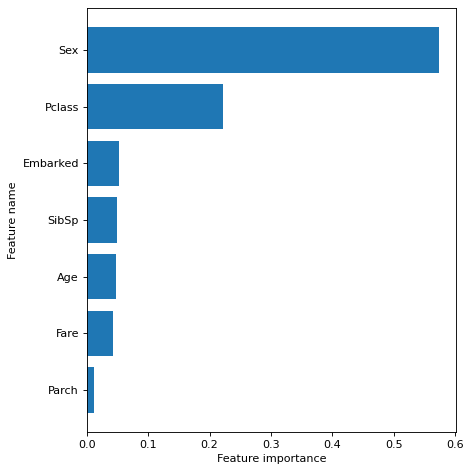

In [18]:
def plot_feature_importances(clf, features):
    features = pd.Series(
        clf.feature_importances_,
        index=features
    ).sort_values(ascending=True)
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), features.values)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(range(c_features), features.index)
    plt.tight_layout()
    plt.show()

plot_feature_importances(xgb_grid.best_estimator_, X_train.columns)

In [19]:
test_predictions = xgb_grid.predict(X_submission)

submission = pd.DataFrame({
    'PassengerId': X_submission.index,
    'Survived':   test_predictions.astype(int)
})

submission_path = os.path.join(path, 'submission.csv')
submission.to_csv(submission_path, index=False)

print(f'Saved: {submission_path}')
print(f'Rows: {len(submission)} (should be 418)')
print(f'Survived: {submission["Survived"].value_counts().to_dict()}')
submission.head(10)

Saved: c:\camp\Camp_2026_homework-main\Camp_2026_homework-main\lesson_8_titanic\data_titanic\submission.csv
Rows: 418 (should be 418)
Survived: {0: 281, 1: 137}


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


![](./data_titanic/Знімок%20екрана%202026-04-20%20150653.png)